In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def show(img, title=None):
    plt.figure(figsize=(6,4))
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

## TASK 1: Circular Mask

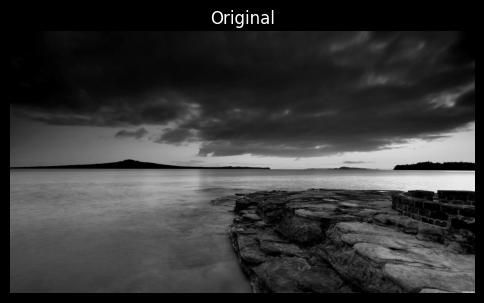

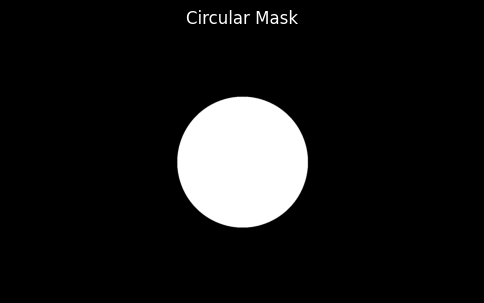

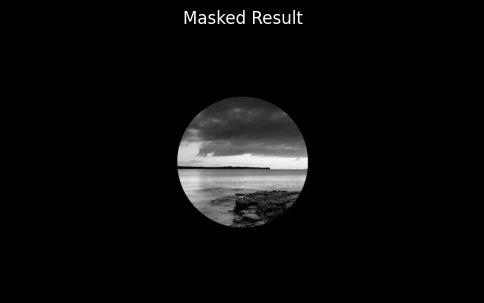

In [2]:
# Load image
img = cv2.imread('40.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create circular mask
h, w = gray.shape
mask = np.zeros((h, w), dtype=np.uint8)
cv2.circle(mask, (w//2, h//2), min(h,w)//4, 255, -1)

# Apply mask
result = cv2.bitwise_and(gray, gray, mask=mask)

show(gray, 'Original')
show(mask, 'Circular Mask')
show(result, 'Masked Result')

## TASK 2: Bit-Plane Slicing

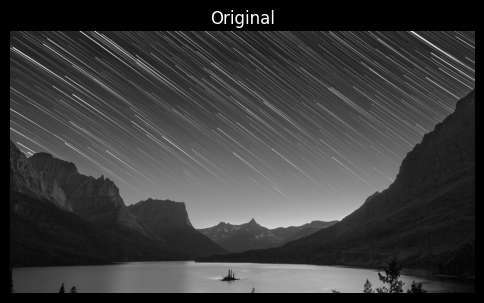

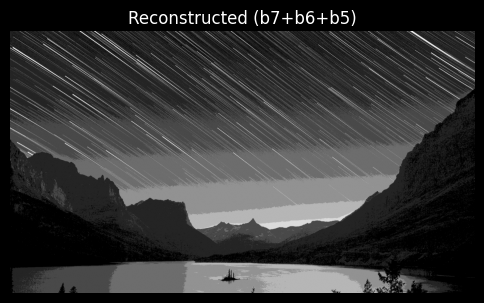

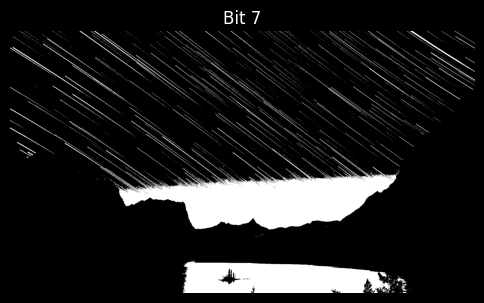

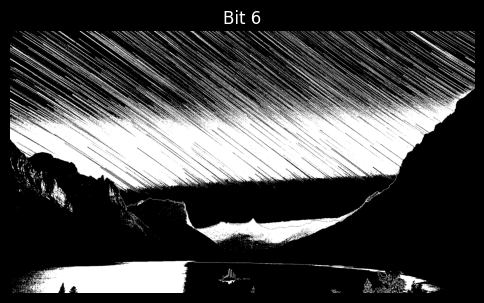

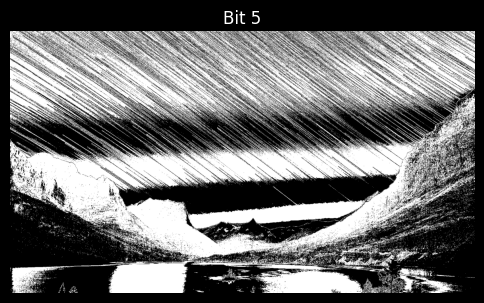

In [3]:
# Load image
img = cv2.imread('79.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Extract bit-planes b7, b6, b5
b7 = (gray & 128) >> 7
b6 = (gray & 64) >> 6
b5 = (gray & 32) >> 5

# Reconstruct
recon = (b7 * 128) + (b6 * 64) + (b5 * 32)

show(gray, 'Original')
show(recon, 'Reconstructed (b7+b6+b5)')
show(b7*255, 'Bit 7')
show(b6*255, 'Bit 6')
show(b5*255, 'Bit 5')

## TASK 3: Histogram Equalization

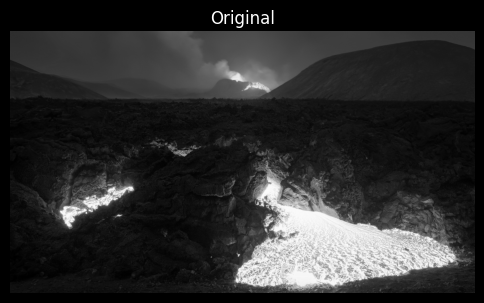

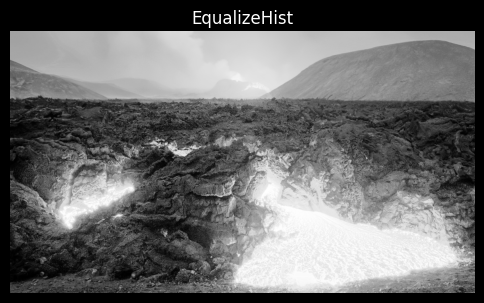

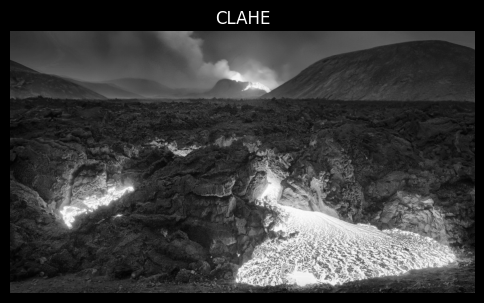

/tmp/ipykernel_390678/1292830547.py:17: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(131); plt.hist(gray.ravel(), 256, [0,256]); plt.title('Original')
/tmp/ipykernel_390678/1292830547.py:18: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(132); plt.hist(eq.ravel(), 256, [0,256]); plt.title('EqualizeHist')
/tmp/ipykernel_390678/1292830547.py:19: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.subplot(133); plt.hist(clahe_img.ravel(), 256, [0,256]); plt.title('CLAHE')


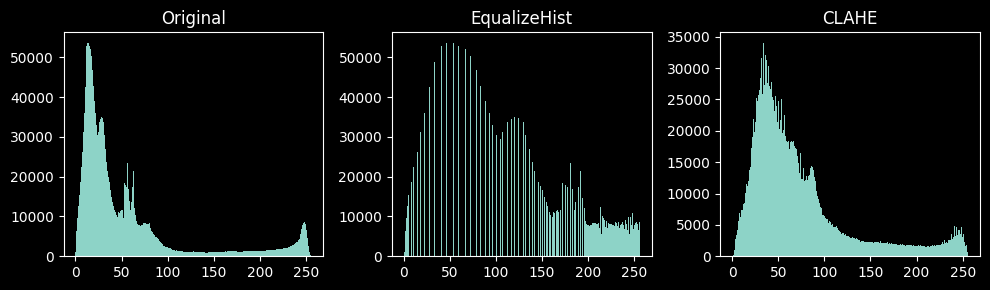

In [4]:
# Load low-contrast image
img = cv2.imread('127.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# EqualizeHist
eq = cv2.equalizeHist(gray)

# CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
clahe_img = clahe.apply(gray)

show(gray, 'Original')
show(eq, 'EqualizeHist')
show(clahe_img, 'CLAHE')

plt.figure(figsize=(10,3))
plt.subplot(131); plt.hist(gray.ravel(), 256, [0,256]); plt.title('Original')
plt.subplot(132); plt.hist(eq.ravel(), 256, [0,256]); plt.title('EqualizeHist')
plt.subplot(133); plt.hist(clahe_img.ravel(), 256, [0,256]); plt.title('CLAHE')
plt.tight_layout()
plt.show()

## TASK 4: Gamma Correction

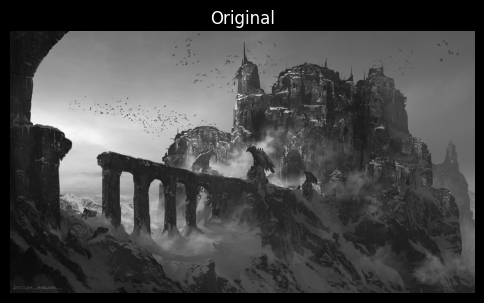

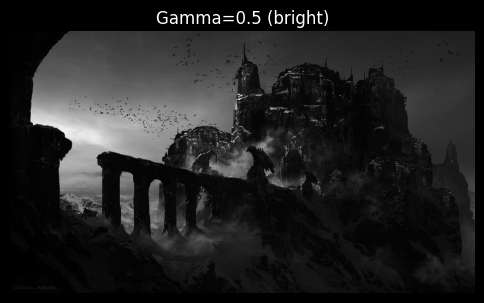

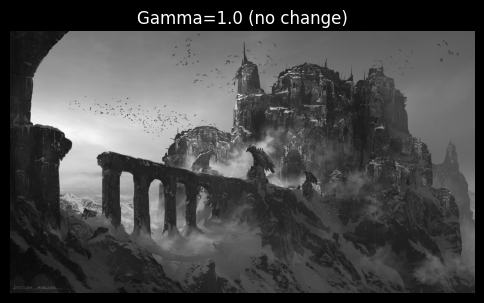

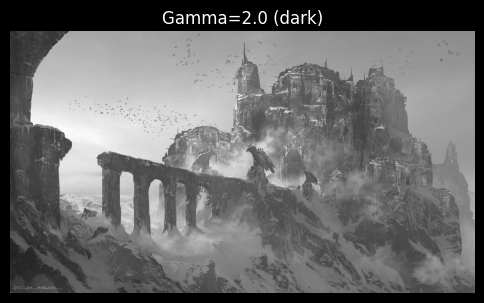

In [5]:
# Load image
img = cv2.imread('233.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

def apply_gamma(img, gamma):
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)], dtype=np.uint8)
    return cv2.LUT(img, table)

show(gray, 'Original')
show(apply_gamma(gray, 0.5), 'Gamma=0.5 (bright)')
show(apply_gamma(gray, 1.0), 'Gamma=1.0 (no change)')
show(apply_gamma(gray, 2.0), 'Gamma=2.0 (dark)')